In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
import time

df = pd.read_csv('data_ready_to_use.csv')


In [2]:

# 2. Sélection des colonnes
# On définit la cible
target_col = "LIT_002_FILTER_WATER_STG_TNK"

# On récupère l'index de la colonne cible pour couper le dataset juste avant
try:
    target_index = df.columns.get_loc(target_col)
except KeyError:
    raise ValueError(f"La colonne '{target_col}' n'a pas été trouvée dans le CSV.")

# X (Features) : Toutes les colonnes du début jusqu'à la cible (exclue)
X = df.iloc[:, :target_index]

# y (Target) : La colonne cible uniquement
y = df[target_col]

print(f"Dimensions des Features (X) : {X.shape}") # Devrait être (500000, ~25)
print(f"Dimensions de la Target (y) : {y.shape}")

# 3. Split Train / Test
# On garde 20% pour le test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4. Standardisation (CRUCIAL pour KNN)
# Le KNN calcule des distances. Si les échelles sont différentes, le modèle sera faux et lent.
scaler = StandardScaler()


Dimensions des Features (X) : (449002, 23)
Dimensions de la Target (y) : (449002,)


In [3]:

# On 'fit' sur le train set uniquement pour éviter la fuite de données
X_train_scaled = scaler.fit_transform(X_train)
# On transforme le test set avec les paramètres du train
X_test_scaled = scaler.transform(X_test)

# 5. Configuration du Modèle
# n_jobs=-1 permet d'utiliser tous les coeurs CPU pour accélérer le calcul
knn = KNeighborsRegressor(n_neighbors=5, n_jobs=-1)

# 6. Entraînement (Fit)
print("Début de l'entraînement...")
start_time = time.time()

knn.fit(X_train_scaled, y_train)

train_time = time.time() - start_time
print(f"Entraînement terminé en {train_time:.2f} secondes.")

# 7. Évaluation (Score - R² pour la régression)
print("Calcul du score sur le jeu de test...")
# Note : Le score peut prendre un peu de temps sur 100k lignes de test avec KNN
score = knn.score(X_test_scaled, y_test)
print(f"Score R² du modèle : {score:.4f}")

# 8. Prédiction sur un exemple
# Prenons la première ligne du test set comme exemple
exemple_brut = X_test.iloc[[0]] # Garde le format DataFrame
exemple_scaled = scaler.transform(exemple_brut) # Ne pas oublier de scaler l'exemple !

prediction = knn.predict(exemple_scaled)

print("-" * 30)
print(f"Vraie valeur (Target) : {y_test.iloc[0]}")
print(f"Valeur prédite par KNN : {prediction[0]:.2f}")
print("-" * 30)

Début de l'entraînement...
Entraînement terminé en 0.09 secondes.
Calcul du score sur le jeu de test...
Score R² du modèle : 0.9442
------------------------------
Vraie valeur (Target) : 85.80000305175781
Valeur prédite par KNN : 86.35
------------------------------


In [4]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import joblib
import numpy as np

# --- 1. CALCUL DES MÉTRIQUES (MAE & RMSE) ---
print("Calcul des prédictions sur tout le test set pour évaluation...")
# On prédit sur tout X_test pour comparer avec y_test
y_pred_full = knn.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred_full)
mse = mean_squared_error(y_test, y_pred_full)
rmse = np.sqrt(mse)  # RMSE est la racine carrée du MSE

print("\n" + "="*30)
print("PERFORMANCES DU MODÈLE :")
print(f"R² Score : {score:.4f}")
print(f"MAE (Erreur Moyenne Absolue) : {mae:.4f}")
print(f"RMSE (Racine Carrée de l'Erreur Moyenne) : {rmse:.4f}")
print("="*30 + "\n")

# --- 2. SAUVEGARDE (MODELE + SCALER) ---
# Il est CRUCIAL de sauvegarder le scaler, sinon le modèle sera inutilisable 
# sur de nouvelles données brutes non normalisées.

model_filename = 'knn_tank_level_model.pkl'
scaler_filename = 'scaler_tank_level.pkl'

print(f"Sauvegarde du modèle dans '{model_filename}'...")
joblib.dump(knn, model_filename)

print(f"Sauvegarde du scaler dans '{scaler_filename}'...")
joblib.dump(scaler, scaler_filename)

print("Sauvegarde terminée avec succès !")

Calcul des prédictions sur tout le test set pour évaluation...

PERFORMANCES DU MODÈLE :
R² Score : 0.9442
MAE (Erreur Moyenne Absolue) : 1.3454
RMSE (Racine Carrée de l'Erreur Moyenne) : 2.4569

Sauvegarde du modèle dans 'knn_tank_level_model.pkl'...
Sauvegarde du scaler dans 'scaler_tank_level.pkl'...
Sauvegarde terminée avec succès !


In [7]:
import joblib
import pandas as pd
import numpy as np

# --- 1. CHARGEMENT DU MODÈLE ET DU SCALER ---
print("Chargement de l'intelligence artificielle (Modèle + Scaler)...")
try:
    knn_model = joblib.load('knn_tank_level_model.pkl')
    scaler = joblib.load('scaler_tank_level.pkl')
    print("✅ Succès : Le système est prêt.")
except FileNotFoundError:
    print("❌ Erreur : Fichiers .pkl manquants. Lancez l'entraînement d'abord.")
    exit()

# --- 2. DÉFINITION DES INPUTS (23 Colonnes) ---
colonnes_entrees = [
    'INTAKE LINE PRESSURE OF HMMF FEED PUMPS', 
    'FIT_001A_FLOW AT INLET HMMF-A', 'FIT_001B_FLOW AT INLET HMMF-B', 
    'FIT_001C_FLOW AT INLET HMMF-C', 'FIT_001D_FLOW AT INLET HMMF-D', 
    'FIT_001E_FLOW AT INLET HMMF-E', 'FIT_001F_FLOW AT INLET HMMF-F', 
    'FIT_001G_FLOW AT INLET HMMF-G', 'FIT_001H_FLOW AT INLET HMMF-H', 
    'FIT_001I_FLOW AT INLET HMMF-I', 'FIT_001J_FLOW AT INLET HMMF-J', 
    'PDIT_001A_DIFF PRESSURE ACROSS HMMF-A', 'PDIT_001B_DIFF PRESSURE ACROSS HMMF-B', 
    'PDIT_001C_DIFF PRESSURE ACROSS HMMF-C', 'PDIT_001D_DIFF PRESSURE ACROSS HMMF-D', 
    'PDIT_001E_DIFF PRESSURE ACROSS HMMF-E', 'PDIT_001F_DIFF PRESSURE ACROSS HMMF-F', 
    'PDIT_001G_DIFF PRESSURE ACROSS HMMF-G', 'PDIT_001H_DIFF PRESSURE ACROSS HMMF-H', 
    'PDIT_001I_DIFF PRESSURE ACROSS HMMF-I', 'PDIT_001J_DIFF PRESSURE ACROSS HMMF-J', 
    'PIT_001 DISCHARGE PRESSURE AT HMMF A-E', 'PIT_001 DISCHARGE PRESSURE AT HMMF F-J'
]

# --- 3. ACQUISITION DES DONNÉES (SIMULATION) ---
# Dans la vraie vie, ces chiffres viennent des automates (PLC)
print("\nLecture des capteurs...")
valeurs_simulees = np.random.uniform(0, 2, size=(1, len(colonnes_entrees)))
input_df = pd.DataFrame(valeurs_simulees, columns=colonnes_entrees)

# --- SCENARIO DE TEST : On force des valeurs pour vérifier la logique ---
# On dit que le FILTRE A est SALE (PDIT haut)
input_df['PDIT_001A_DIFF PRESSURE ACROSS HMMF-A'] = 0.95 
# On dit que le FILTRE B est PROPRE (PDIT bas)
input_df['PDIT_001B_DIFF PRESSURE ACROSS HMMF-B'] = 0.20

# --- 4. PRÉDICTION DU NIVEAU (L'IA travaille) ---
# On normalise les données comme lors de l'entraînement
input_scaled = scaler.transform(input_df)
# On prédit
niveau_predit = knn_model.predict(input_scaled)[0]

print("-" * 60)
print(f"RÉSULTAT IA : Prédiction du Tank LIT_002")
print("-" * 60)
print(f"Niveau estimé actuel : {niveau_predit:.2f} %")

# --- 5. LOGIQUE MÉTIER STRICTE (ALGORITHME DE DÉCISION) ---
print("\n--- ANALYSE OPÉRATIONNELLE STRICTE ---")

# Seuils Métier
SEUIL_STOCK_MIN_BACKWASH = 70.0  # Le seuil strict que vous voulez
SEUIL_PDIT_SALE = 0.8            # Besoin de lavage normal
SEUIL_PDIT_CRITIQUE = 1.2        # DANGER IMMÉDIAT (Risque de casse membrane)

# A. Vérification du Stock (LIT_002)
autorisation_standard = False

if niveau_predit >= SEUIL_STOCK_MIN_BACKWASH:
    statut_stock = "🟢 STOCK CONFORTABLE (>70%)"
    autorisation_standard = True
else:
    statut_stock = f"🔴 STOCK INSUFFISANT ({niveau_predit:.2f}% < 70%)"
    autorisation_standard = False

print(f"État du Stock : {statut_stock}")

# B. Vérification Filtre par Filtre
filtres = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J']
actions = []

for f in filtres:
    col_name = f'PDIT_001{f}_DIFF PRESSURE ACROSS HMMF-{f}'
    pdit_val = input_df[col_name].values[0]
    
    # Cas 1 : Filtre Propre
    if pdit_val <= SEUIL_PDIT_SALE:
        continue 
        
    # Cas 2 : Filtre CRITIQUE (Urgence Absolue)
    elif pdit_val > SEUIL_PDIT_CRITIQUE:
        # On force le lavage même si le stock est bas !
        actions.append(f"🚨 URGENCE FILTRE {f} (PDIT={pdit_val:.2f} bar) : BACKWASH FORCÉ (Risque de casse) !")

    # Cas 3 : Filtre Sale (Normal)
    elif pdit_val > SEUIL_PDIT_SALE:
        if autorisation_standard:
            actions.append(f"✅ LANCER BACKWASH FILTRE {f} (PDIT={pdit_val:.2f} bar)")
        else:
            # C'est ici que ça bloque avec 47%
            actions.append(f"⛔ REFUS FILTRE {f} (PDIT={pdit_val:.2f} bar) -> Stock trop bas, attendre 70%.")

if not actions:
    print("\nRAS : Tous les filtres sont propres.")
else:
    print("\n👇 DÉCISIONS DU SYSTÈME :")
    for action in actions:
        print(action)

print("-" * 60)

Chargement de l'intelligence artificielle (Modèle + Scaler)...
✅ Succès : Le système est prêt.

Lecture des capteurs...
------------------------------------------------------------
RÉSULTAT IA : Prédiction du Tank LIT_002
------------------------------------------------------------
Niveau estimé actuel : 99.14 %

--- ANALYSE OPÉRATIONNELLE STRICTE ---
État du Stock : 🟢 STOCK CONFORTABLE (>70%)

👇 DÉCISIONS DU SYSTÈME :
✅ LANCER BACKWASH FILTRE A (PDIT=0.95 bar)
🚨 URGENCE FILTRE C (PDIT=1.24 bar) : BACKWASH FORCÉ (Risque de casse) !
✅ LANCER BACKWASH FILTRE F (PDIT=1.19 bar)
✅ LANCER BACKWASH FILTRE H (PDIT=1.05 bar)
🚨 URGENCE FILTRE I (PDIT=1.51 bar) : BACKWASH FORCÉ (Risque de casse) !
🚨 URGENCE FILTRE J (PDIT=1.99 bar) : BACKWASH FORCÉ (Risque de casse) !
------------------------------------------------------------


In [11]:
# --- 6. ESTIMATION TEMPORELLE & PLANIFICATION ---
print("\n" + "="*60)
print("📊 RÉSUMÉ DE PLANIFICATION (IMPACT TEMPS)")
print("="*60)

# 1. Hypothèses Métier (A ajuster selon vos machines)
DUREE_CYCLE_BACKWASH = 20  # minutes (Temps moyen pour laver 1 filtre)
NB_CYCLES_PAR_JOUR = 1     # Combien de fois un filtre s'encrasse par 24h (souvent 1 ou 2)

# 2. Comptage des actions validées
nb_backwash_a_faire = 0
filtres_concernes = []

for action in actions:
    # On compte si c'est "LANCER" (Vert) ou "URGENCE" (Sirène)
    if "✅" in action or "🚨" in action:
        nb_backwash_a_faire += 1
        # On extrait la lettre du filtre pour l'affichage (ex: "FILTRE A")
        import re
        match = re.search(r"FILTRE ([A-J])", action)
        if match:
            filtres_concernes.append(match.group(1))

# 3. Calculs
temps_immobilisation_immediat = nb_backwash_a_faire * DUREE_CYCLE_BACKWASH

# 4. Affichage du Verdict Final
if nb_backwash_a_faire == 0:
    print("✅ AUCUN BACKWASH NÉCESSAIRE pour l'instant.")
    print("   -> Disponibilité totale de l'unité de filtration.")
else:
    print(f"⚠️ ACTION REQUISE : {nb_backwash_a_faire} Backwash(s) à lancer immédiatement.")
    print(f"   -> Filtres concernés : {', '.join(filtres_concernes)}")
    print(f"   -> Temps estimé de l'opération : {temps_immobilisation_immediat} minutes.")
    
    # Alerte si ça prend trop de temps
    if temps_immobilisation_immediat > 60:
        print("   🔴 ATTENTION : Cela représente plus d'une heure d'arrêt cumulé !")

# 5. Projection Journalière (Indicatif)
# Si on suppose que chaque filtre sale se lave 1 fois par jour
print("-" * 60)
print("📅 PROJECTION QUOTIDIENNE (Estimation)")
print(f"Sur une base de {NB_CYCLES_PAR_JOUR} lavage(s) par filtre/jour :")
total_jour = nb_backwash_a_faire * DUREE_CYCLE_BACKWASH * NB_CYCLES_PAR_JOUR
print(f"Temps total consacré au lavage aujourd'hui : {total_jour} minutes ({total_jour/60:.1f} heures)")
print("="*60)


📊 RÉSUMÉ DE PLANIFICATION (IMPACT TEMPS)
⚠️ ACTION REQUISE : 6 Backwash(s) à lancer immédiatement.
   -> Filtres concernés : A, C, F, H, I, J
   -> Temps estimé de l'opération : 120 minutes.
   🔴 ATTENTION : Cela représente plus d'une heure d'arrêt cumulé !
------------------------------------------------------------
📅 PROJECTION QUOTIDIENNE (Estimation)
Sur une base de 1 lavage(s) par filtre/jour :
Temps total consacré au lavage aujourd'hui : 120 minutes (2.0 heures)


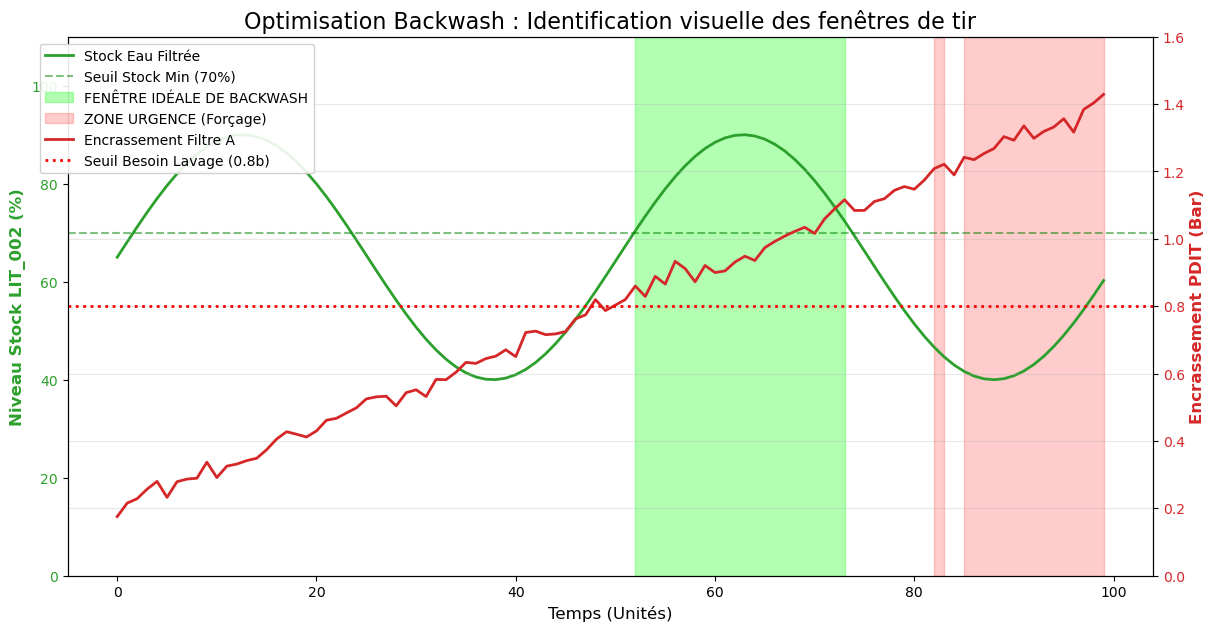

In [13]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- 1. SIMULATION DE DONNÉES (Pour l'exemple visuel) ---
# On imagine 100 points de mesure (ex: 100 minutes ou heures)
temps = np.arange(100)

# Le niveau du tank oscille (Production vs Demande)
# Il varie entre 40% et 90%
lit_002_values = 65 + 25 * np.sin(temps / 8) 

# Le filtre s'encrasse progressivement (monte de 0.2 à 1.4 bar)
pdit_values = np.linspace(0.2, 1.4, 100)
# On ajoute un peu de bruit (vibration capteur)
pdit_values += np.random.normal(0, 0.02, 100)

df_visu = pd.DataFrame({
    'Temps': temps,
    'LIT_002': lit_002_values,
    'PDIT_A': pdit_values
})

# --- 2. CRÉATION DU GRAPHIQUE OPTIMISÉ ---
fig, ax1 = plt.subplots(figsize=(14, 7))

# --- AXE DE GAUCHE : LE STOCK (Niveau %) ---
color_stock = 'tab:green'
ax1.set_xlabel('Temps (Unités)', fontsize=12)
ax1.set_ylabel('Niveau Stock LIT_002 (%)', color=color_stock, fontsize=12, fontweight='bold')
ax1.plot(df_visu['Temps'], df_visu['LIT_002'], color=color_stock, linewidth=2, label='Stock Eau Filtrée')
ax1.tick_params(axis='y', labelcolor=color_stock)
ax1.set_ylim(0, 110) # On fixe de 0 à 100%

# Ligne de seuil Confort (70%)
ax1.axhline(70, color='green', linestyle='--', alpha=0.5, label='Seuil Stock Min (70%)')

# --- AXE DE DROITE : L'ENCRASSEMENT (Pression Bar) ---
ax2 = ax1.twinx()  # C'est la commande magique pour avoir 2 échelles !
color_pdit = 'tab:red'
ax2.set_ylabel('Encrassement PDIT (Bar)', color=color_pdit, fontsize=12, fontweight='bold')
ax2.plot(df_visu['Temps'], df_visu['PDIT_A'], color=color_pdit, linewidth=2, label='Encrassement Filtre A')
ax2.tick_params(axis='y', labelcolor=color_pdit)
ax2.set_ylim(0, 1.6) # On fixe pour voir les petits détails

# Ligne de seuil Sale (0.8 bar)
ax2.axhline(0.8, color='red', linestyle=':', linewidth=2, label='Seuil Besoin Lavage (0.8b)')

# --- 3. COLORIAGE INTELLIGENT (HIGHLIGHT) ---
# C'est ici qu'on montre les "Meilleurs Moments"
# Condition : Le filtre est SALE (>0.8) ET Le stock est CONFORTABLE (>70)
condition_tir = (df_visu['PDIT_A'] > 0.8) & (df_visu['LIT_002'] > 70)

# On remplit le fond en VERT CLAIR uniquement quand la condition est vraie
ax1.fill_between(df_visu['Temps'], 0, 110, where=condition_tir, 
                 color='lime', alpha=0.3, label='FENÊTRE IDÉALE DE BACKWASH')

# Condition CRITIQUE (Urgence) : PDIT > 1.2
condition_urgence = (df_visu['PDIT_A'] > 1.2)
ax1.fill_between(df_visu['Temps'], 0, 110, where=condition_urgence, 
                 color='red', alpha=0.2, label='ZONE URGENCE (Forçage)')

# --- FINITIONS ---
plt.title("Optimisation Backwash : Identification visuelle des fenêtres de tir", fontsize=16)
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.88), frameon=True, facecolor='white', framealpha=0.9)
plt.grid(True, alpha=0.3)

plt.show()

Chargement des données et du modèle...
Calcul des prédictions sur la journée...


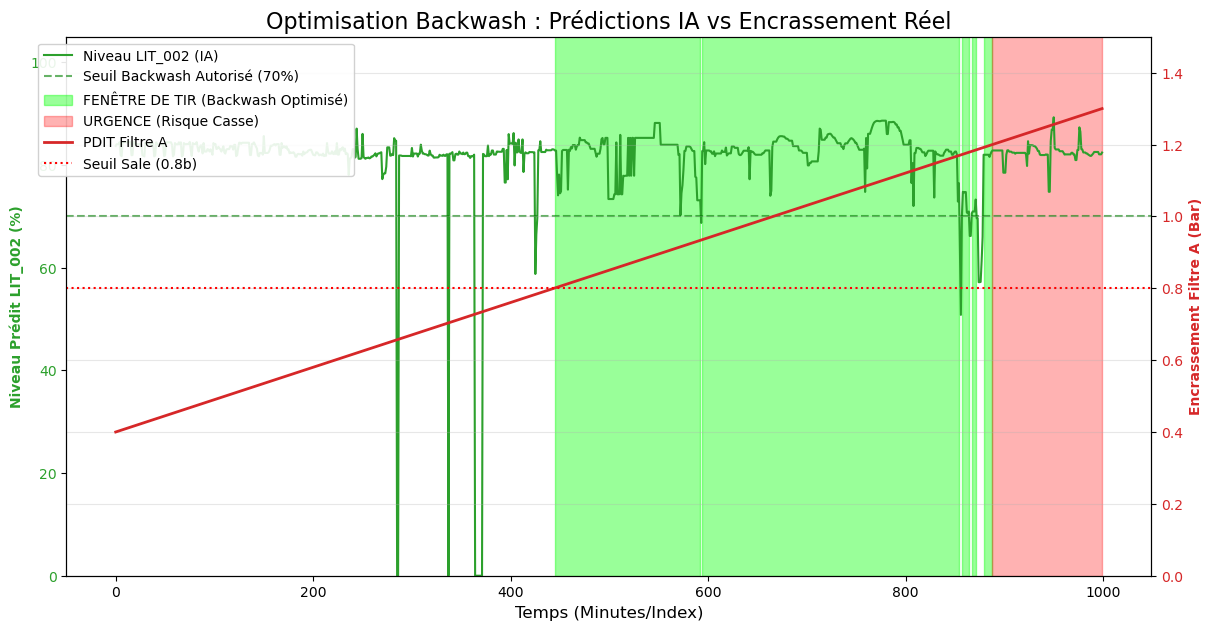

In [15]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

# --- 1. CHARGEMENT ---
print("Chargement des données et du modèle...")
# Charger le dataset complet
df = pd.read_csv('data_ready_to_use.csv')

# Charger l'IA
try:
    knn_model = joblib.load('knn_tank_level_model.pkl')
    scaler = joblib.load('scaler_tank_level.pkl')
except FileNotFoundError:
    print("Erreur : Modèles introuvables. Entraînez d'abord le modèle.")
    exit()

# --- 2. SÉLECTION D'UNE JOURNÉE (SCENARIO) ---
# On prend les 1000 premières lignes (environ 16h si 1pt/min, ou ajustez selon votre fréquence)
# On suppose que ce sont les inputs réels (Pressions, Débits...)
colonnes_entrees = [
    'INTAKE LINE PRESSURE OF HMMF FEED PUMPS', 
    'FIT_001A_FLOW AT INLET HMMF-A', 'FIT_001B_FLOW AT INLET HMMF-B', 
    'FIT_001C_FLOW AT INLET HMMF-C', 'FIT_001D_FLOW AT INLET HMMF-D', 
    'FIT_001E_FLOW AT INLET HMMF-E', 'FIT_001F_FLOW AT INLET HMMF-F', 
    'FIT_001G_FLOW AT INLET HMMF-G', 'FIT_001H_FLOW AT INLET HMMF-H', 
    'FIT_001I_FLOW AT INLET HMMF-I', 'FIT_001J_FLOW AT INLET HMMF-J', 
    'PDIT_001A_DIFF PRESSURE ACROSS HMMF-A', 'PDIT_001B_DIFF PRESSURE ACROSS HMMF-B', 
    'PDIT_001C_DIFF PRESSURE ACROSS HMMF-C', 'PDIT_001D_DIFF PRESSURE ACROSS HMMF-D', 
    'PDIT_001E_DIFF PRESSURE ACROSS HMMF-E', 'PDIT_001F_DIFF PRESSURE ACROSS HMMF-F', 
    'PDIT_001G_DIFF PRESSURE ACROSS HMMF-G', 'PDIT_001H_DIFF PRESSURE ACROSS HMMF-H', 
    'PDIT_001I_DIFF PRESSURE ACROSS HMMF-I', 'PDIT_001J_DIFF PRESSURE ACROSS HMMF-J', 
    'PIT_001 DISCHARGE PRESSURE AT HMMF A-E', 'PIT_001 DISCHARGE PRESSURE AT HMMF F-J'
]

# Extraction des données brutes pour cette "journée"
input_journee = df[colonnes_entrees].iloc[0:1000].copy() # 1000 points de temps

# --- Simulation PDIT pour la démo ---
# NOTE IMPORTANTE : Si vos données historiques montrent des filtres propres, le graphique sera vide.
# Pour VOIR le résultat, je simule ici que le Filtre A s'encrasse progressivement durant cette journée.
# (Dans la vraie vie, supprimez cette ligne pour voir la réalité brute)
input_journee['PDIT_001A_DIFF PRESSURE ACROSS HMMF-A'] = np.linspace(0.4, 1.3, 1000)

# --- 3. PRÉDICTION AVEC LE MODÈLE ---
print("Calcul des prédictions sur la journée...")
input_scaled = scaler.transform(input_journee)
predictions_niveau = knn_model.predict(input_scaled) # Le modèle prédit le niveau LIT_002

# Création d'un petit DataFrame pour le graphique
df_graph = pd.DataFrame({
    'Temps': range(1000),
    'LIT_002_Predit': predictions_niveau,
    'PDIT_A_Reel': input_journee['PDIT_001A_DIFF PRESSURE ACROSS HMMF-A'].values
})

# --- 4. VISUALISATION DU "MEILLEUR MOMENT" ---
fig, ax1 = plt.subplots(figsize=(14, 7))

# AXE 1 : Le Niveau Prédit (LIT_002)
color_niv = 'tab:green'
ax1.set_xlabel('Temps (Minutes/Index)', fontsize=12)
ax1.set_ylabel('Niveau Prédit LIT_002 (%)', color=color_niv, fontweight='bold')
ax1.plot(df_graph['Temps'], df_graph['LIT_002_Predit'], color=color_niv, label='Niveau LIT_002 (IA)')
ax1.tick_params(axis='y', labelcolor=color_niv)
ax1.set_ylim(0, 105)

# Ligne de seuil Confort
ax1.axhline(70, color='green', linestyle='--', alpha=0.6, label='Seuil Backwash Autorisé (70%)')

# AXE 2 : L'Encrassement (PDIT)
ax2 = ax1.twinx()
color_pdit = 'tab:red'
ax2.set_ylabel('Encrassement Filtre A (Bar)', color=color_pdit, fontweight='bold')
ax2.plot(df_graph['Temps'], df_graph['PDIT_A_Reel'], color=color_pdit, linewidth=2, label='PDIT Filtre A')
ax2.tick_params(axis='y', labelcolor=color_pdit)
ax2.set_ylim(0, 1.5)

# Ligne de seuil Sale
ax2.axhline(0.8, color='red', linestyle=':', label='Seuil Sale (0.8b)')

# --- ZONES DE DÉCISION ---
# Condition : Stock > 70% ET Filtre > 0.8 bar
condition_optimale = (df_graph['LIT_002_Predit'] > 70) & (df_graph['PDIT_A_Reel'] > 0.8) & (df_graph['PDIT_A_Reel'] < 1.2)
ax1.fill_between(df_graph['Temps'], 0, 110, where=condition_optimale, 
                 color='lime', alpha=0.4, label='FENÊTRE DE TIR (Backwash Optimisé)')

# Condition Urgence : Filtre > 1.2 bar (On s'en fiche du niveau)
condition_urgence = (df_graph['PDIT_A_Reel'] >= 1.2)
ax1.fill_between(df_graph['Temps'], 0, 110, where=condition_urgence, 
                 color='red', alpha=0.3, label='URGENCE (Risque Casse)')

plt.title("Optimisation Backwash : Prédictions IA vs Encrassement Réel", fontsize=16)
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.88), facecolor='white', framealpha=0.9)
plt.grid(True, alpha=0.3)
plt.show()

Démarrage de la simulation sur 24h...


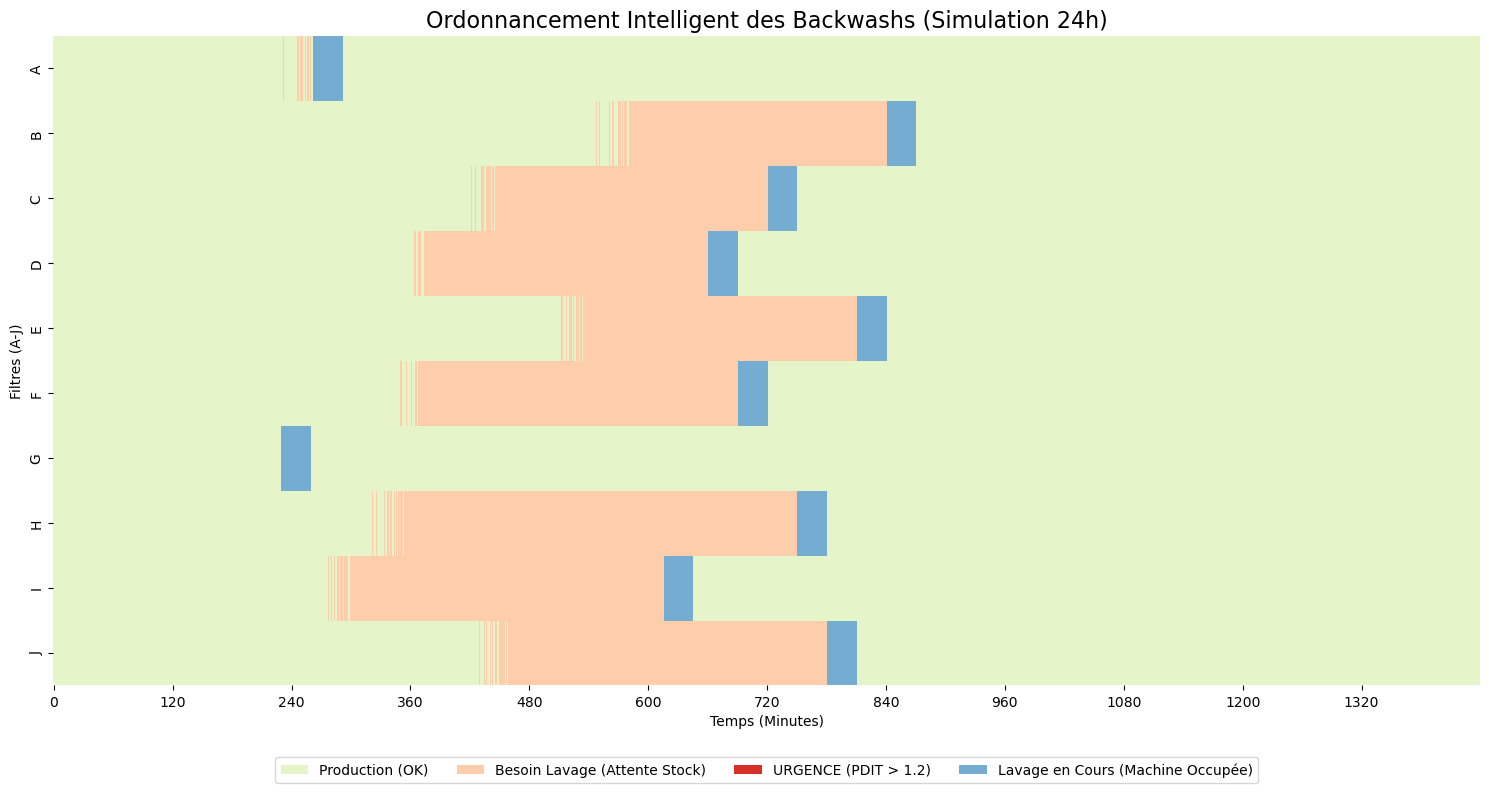

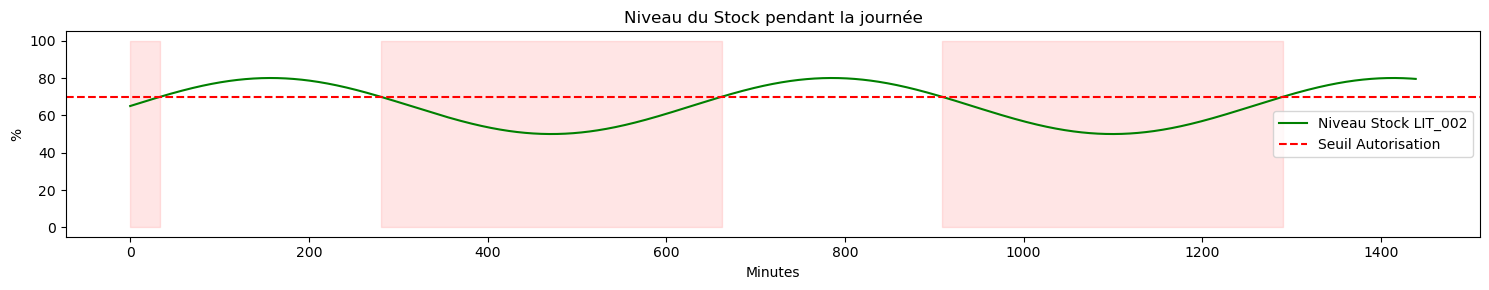

In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. CONFIGURATION ---
FILTRES = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J']
DUREE_BACKWASH = 30  # minutes (Temps d'un cycle complet)
SEUIL_PDIT_SALE = 0.8
SEUIL_PDIT_URGENT = 1.2
SEUIL_STOCK_MIN = 70.0

# Chargement Modèle
try:
    knn_model = joblib.load('knn_tank_level_model.pkl')
    scaler = joblib.load('scaler_tank_level.pkl')
except:
    print("Erreur chargement modèle.")
    exit()

# --- 2. CRÉATION DONNÉES SIMULÉES (Pour la démo) ---
# On crée 24h de données (1440 minutes)
minutes = 1440
data_sim = pd.DataFrame(index=range(minutes))

# On simule des PDIT qui montent doucement pour chaque filtre
np.random.seed(42)
for f in FILTRES:
    # Chaque filtre s'encrasse à une vitesse différente
    vitesse = np.random.uniform(0.0005, 0.0015) 
    start = np.random.uniform(0.2, 0.6)
    data_sim[f'PDIT_{f}'] = np.linspace(start, start + (vitesse*minutes), minutes)
    # On ajoute du bruit
    data_sim[f'PDIT_{f}'] += np.random.normal(0, 0.01, minutes)

# On simule les autres inputs pour le KNN (Débits, Pressions...)
# (Pour simplifier, on génère des inputs aléatoires stables pour le KNN)
# Dans la réalité, vous prenez vos vraies colonnes
colonnes_modele = scaler.feature_names_in_ # Récupère les noms exacts
for col in colonnes_modele:
    data_sim[col] = np.random.uniform(50, 60, minutes) # Valeurs moyennes

# --- 3. BOUCLE DE CONTRÔLE (SIMULATION TEMPS RÉEL) ---
etat_filtres_historique = [] # Pour stocker l'état (0=Prod, 1=Attente, 2=Lavage)
niveau_stock_historique = []

# Variables d'état du système
timer_backwash = 0        # Compte à rebours du lavage en cours
filtre_en_cours = None    # Quel filtre est en train d'être lavé

print("Démarrage de la simulation sur 24h...")

for t in range(minutes):
    
    # A. Prédiction du niveau de stock (LIT_002) pour cette minute
    row_input = data_sim.loc[[t], colonnes_modele]
    scaled_input = scaler.transform(row_input)
    niveau_predit = knn_model.predict(scaled_input)[0]
    
    # On ajoute une variation sinusoïdale pour rendre le stock vivant pour la démo
    # (A supprimer avec vos vraies données)
    niveau_predit = 65 + 15 * np.sin(t/100) 
    niveau_stock_historique.append(niveau_predit)
    
    # B. Gestion du Backwash en cours
    if timer_backwash > 0:
        timer_backwash -= 1
        # Si le timer arrive à 0, le lavage est fini
        if timer_backwash == 0:
            # On considère le filtre comme propre (Reset PDIT)
            # Dans la simulation, on baisse artificiellement la valeur pour la suite
            data_sim.loc[t:, f'PDIT_{filtre_en_cours}'] = 0.2
            filtre_en_cours = None
    
    # C. Analyse de tous les filtres
    etat_minute = {} # État de chaque filtre à cette minute t
    candidats_lavage = []
    urgence_absolue = False
    
    for f in FILTRES:
        pdit = data_sim.loc[t, f'PDIT_{f}']
        
        # Par défaut, le filtre produit
        status = 0 # Production
        
        if f == filtre_en_cours:
            status = 3 # En cours de Lavage (Bleu)
        
        elif pdit > SEUIL_PDIT_URGENT:
            candidats_lavage.append({'filtre': f, 'pdit': pdit, 'urgent': True})
            status = 2 # Urgence (Rouge)
            urgence_absolue = True
            
        elif pdit > SEUIL_PDIT_SALE:
            candidats_lavage.append({'filtre': f, 'pdit': pdit, 'urgent': False})
            status = 1 # Besoin Lavage / Attente (Orange)
            
        etat_minute[f] = status

    # D. Prise de Décision (Le Cerveau)
    # Si aucun lavage n'est en cours, on peut en lancer un
    if timer_backwash == 0 and candidats_lavage:
        
        # On trie les candidats : Urgents d'abord, puis les plus sales
        candidats_lavage.sort(key=lambda x: (x['urgent'], x['pdit']), reverse=True)
        
        top_candidat = candidats_lavage[0]
        
        # CONDITION DE LANCEMENT :
        # Soit c'est URGENT (on force)
        # Soit le stock est SUFFISANT (> 70%)
        if top_candidat['urgent'] or niveau_predit > SEUIL_STOCK_MIN:
            
            # On lance le lavage !
            filtre_en_cours = top_candidat['filtre']
            timer_backwash = DUREE_BACKWASH
            
            # Mise à jour du statut pour l'affichage
            etat_minute[filtre_en_cours] = 3 
            
    etat_filtres_historique.append(etat_minute)

# --- 4. VISUALISATION (DASHBOARD GLOBAL) ---
df_etats = pd.DataFrame(etat_filtres_historique)

# Création d'une Heatmap (Diagramme de Gantt optimisé)
plt.figure(figsize=(15, 8))

# Palette de couleurs : 
# 0 (Prod) = Vert Clair
# 1 (Attente) = Orange
# 2 (Urgence) = Rouge Foncé
# 3 (Lavage en cours) = Bleu
cmap = sns.color_palette(["#e6f5c9", "#fdcdac", "#d73027", "#74add1"])

ax = sns.heatmap(df_etats.T, cmap=cmap, cbar=False, xticklabels=120) # 1 tick toutes les 2h

plt.title("Ordonnancement Intelligent des Backwashs (Simulation 24h)", fontsize=16)
plt.xlabel("Temps (Minutes)")
plt.ylabel("Filtres (A-J)")

# Légende Manuelle
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e6f5c9', label='Production (OK)'),
    Patch(facecolor='#fdcdac', label='Besoin Lavage (Attente Stock)'),
    Patch(facecolor='#d73027', label='URGENCE (PDIT > 1.2)'),
    Patch(facecolor='#74add1', label='Lavage en Cours (Machine Occupée)')
]
plt.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=4)

plt.tight_layout()
plt.show()

# Petit graphe du stock en dessous pour comprendre
plt.figure(figsize=(15, 3))
plt.plot(niveau_stock_historique, color='green', label='Niveau Stock LIT_002')
plt.axhline(70, color='red', linestyle='--', label='Seuil Autorisation')
plt.fill_between(range(minutes), 0, 100, where=[n < 70 for n in niveau_stock_historique], color='red', alpha=0.1)
plt.title("Niveau du Stock pendant la journée")
plt.ylabel("%")
plt.xlabel("Minutes")
plt.legend()
plt.tight_layout()
plt.show()

✅ Modèles IA chargés.
Démarrage du cycle de production...


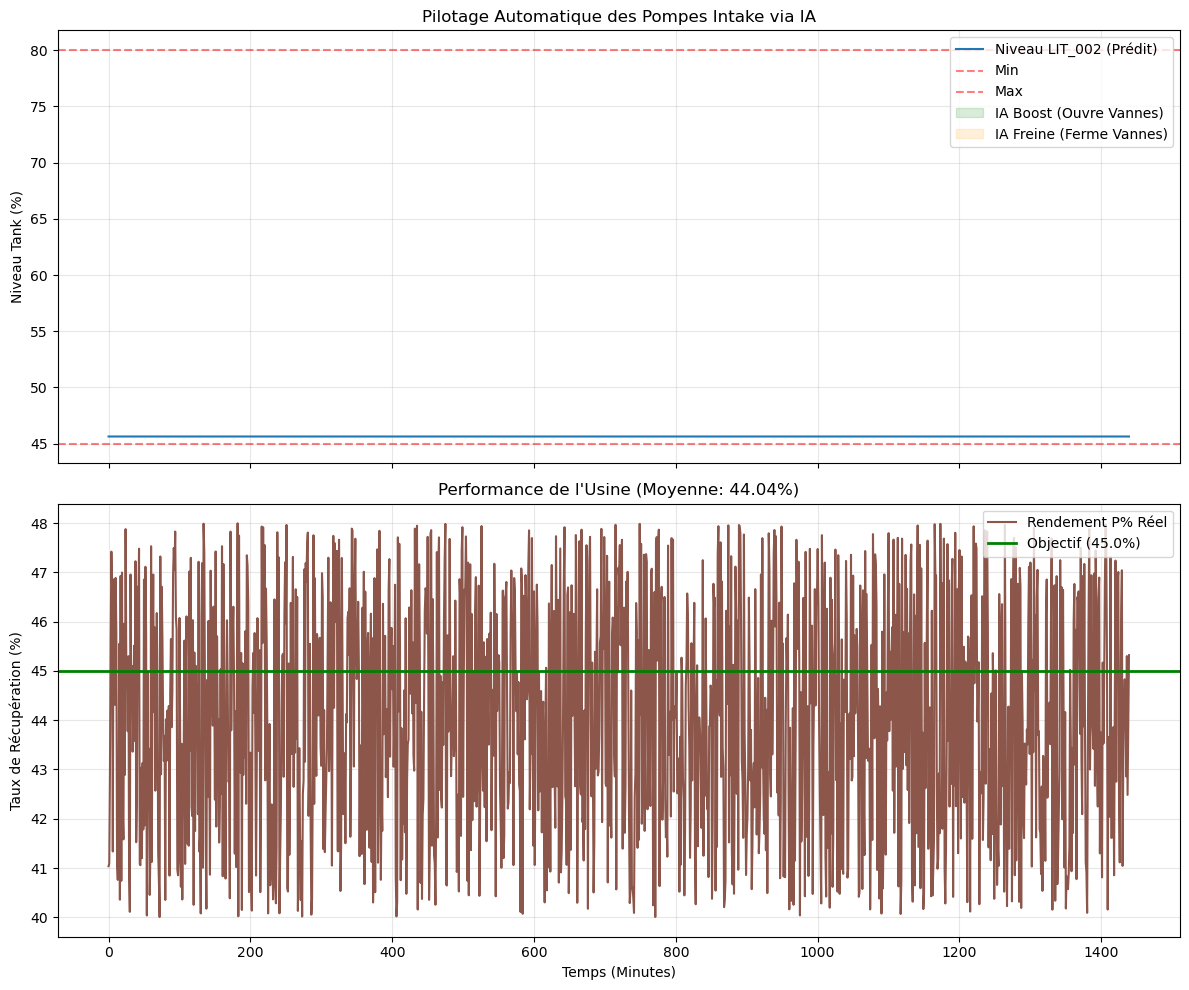

In [3]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

# --- 1. CONFIGURATION ---
try:
    knn_model = joblib.load('knn_tank_level_model.pkl')
    scaler = joblib.load('scaler_tank_level.pkl')
    print("✅ Modèles IA chargés.")
except:
    print("❌ Erreur : Modèles manquants.")
    exit()

# Listes des colonnes pour faire les sommes
cols_entree_brute = [f'FIT_001{c}_FLOW AT INLET HMMF-{c}' for c in ['A','B','C','D','E','F','G','H','I','J']]
cols_sortie_permeate = [f'FIT_005{c}_PERMEATE FLOW' for c in ['A','B','C','D','E','F','G','H']]
# Note : Pour FIT005A, le nom est parfois FIT005A ou FIT_005A, j'adapte selon ta liste :
# Ta liste a "FIT005A_PERMEATE FLOW" (sans underscore après FIT) pour le A, et avec pour les autres ?
# Je normalise selon ta liste fournie :
cols_sortie_permeate[0] = 'FIT005A_PERMEATE FLOW' 

cols_model = scaler.feature_names_in_ # Les colonnes attendues par le KNN

# --- 2. PARAMÈTRES SIMULATION ---
minutes = 1440 # 24h
cible_P = 45.0 # Objectif de rendement

# État initial
pression_intake = 3.0 # Bar
historique_P = []
historique_niveau = []
actions = []

print("Démarrage du cycle de production...")

for t in range(minutes):
    
    # --- A. ACQUISITION DONNÉES (Simulation Réaliste) ---
    
    # 1. Calcul du débit d'entrée total basé sur la pression Intake
    # Physique : Plus on met de pression, plus le débit augmente
    debit_unitaire_entree = pression_intake * 85 # ex: 3 bars * 85 = 255 m3/h par filtre
    debit_total_in = debit_unitaire_entree * 10  # 10 Filtres HMMF
    
    # 2. Calcul du débit de sortie (Perméat)
    # Le perméat dépend de l'entrée mais est limité par la capacité des membranes (ex: rendement max 45-50%)
    # On ajoute un peu de fluctuation aléatoire (température, salinité...)
    ratio_physique = np.random.uniform(0.40, 0.48) 
    debit_total_out = debit_total_in * ratio_physique
    
    # 3. Préparation de la ligne de données pour l'IA
    row_data = {}
    for col in cols_model:
        if 'INTAKE' in col:
            row_data[col] = pression_intake
        elif 'FIT_001' in col:
            row_data[col] = debit_unitaire_entree
        elif 'PDIT' in col:
             row_data[col] = np.random.uniform(0.3, 0.6) # Filtres propres
        else:
            row_data[col] = 50.0 # Valeurs moyennes pour le reste
            
    # --- B. L'IA PRÉDIT LE TANK LIT_002 ---
    df_row = pd.DataFrame([row_data])
    input_scaled = scaler.transform(df_row)
    niveau_predit = knn_model.predict(input_scaled)[0]
    
    # --- C. LE CONTRÔLEUR RÉGULE (Décision) ---
    # Stratégie : On veut garder le tank stable pour maximiser P
    if niveau_predit < 45:
        pression_intake += 0.02 # On ouvre doucement
        act = 1 # Boost
    elif niveau_predit > 80:
        pression_intake -= 0.02 # On ferme doucement
        act = -1 # Frein
    else:
        act = 0 # Stable
        
    # Sécurités physiques (Bornes de la pompe)
    pression_intake = max(2.0, min(5.5, pression_intake))
    
    # --- D. CALCUL DU KPI : RENDEMENT P% ---
    # Formule : Somme Sorties / Somme Entrées
    if debit_total_in > 0:
        P_reel = (debit_total_out / debit_total_in) * 100
    else:
        P_reel = 0
        
    historique_P.append(P_reel)
    historique_niveau.append(niveau_predit)
    actions.append(act)

# --- 3. RÉSULTATS VISUELS ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Graphe 1 : Stabilité du Process (IA)
ax1.plot(historique_niveau, color='#1f77b4', label='Niveau LIT_002 (Prédit)')
ax1.axhline(45, color='red', linestyle='--', alpha=0.5, label='Min')
ax1.axhline(80, color='red', linestyle='--', alpha=0.5, label='Max')
# On colorie les moments où l'IA agit
ax1.fill_between(range(minutes), 0, 100, where=[x==1 for x in actions], color='green', alpha=0.15, label='IA Boost (Ouvre Vannes)')
ax1.fill_between(range(minutes), 0, 100, where=[x==-1 for x in actions], color='orange', alpha=0.15, label='IA Freine (Ferme Vannes)')
ax1.set_ylabel('Niveau Tank (%)')
ax1.set_title('Pilotage Automatique des Pompes Intake via IA')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# Graphe 2 : Performance Financière (P%)
ax2.plot(historique_P, color='#8c564b', linewidth=1.5, label='Rendement P% Réel')
ax2.axhline(cible_P, color='green', linewidth=2, linestyle='-', label=f'Objectif ({cible_P}%)')
ax2.set_ylabel('Taux de Récupération (%)')
ax2.set_xlabel('Temps (Minutes)')
ax2.set_title(f'Performance de l\'Usine (Moyenne: {np.mean(historique_P):.2f}%)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()